In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Read dataset
df_new = pd.read_csv(r"C:\Users\charulatha\OneDrive\Desktop\Project_Analysis\Nutri_Class_project\Data\cleaned_encoded_food_dataset.csv")

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


X = df_new.drop(columns=["Food_Name_label"])
y = df_new["Food_Name_label"]

# Stratified split (VERY important for imbalanced classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

y_pred1_gb = gb.predict(X_train)
y_pred2_gb = gb.predict(X_test)


In [6]:
# Accurcy score train and test
print("Train Accuracy:", accuracy_score(y_train, y_pred1_gb))
print("Test Accuracy:", accuracy_score(y_test, y_pred2_gb))
print(classification_report(y_test, y_pred2_gb))

Train Accuracy: 0.9980446927374301
Test Accuracy: 0.9942537909018356
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       295
           1       1.00      0.99      1.00       237
           2       0.99      0.99      0.99       988
           3       1.00      1.00      1.00       893
           4       0.99      1.00      1.00       593
           5       1.00      1.00      1.00       792
           6       0.99      0.99      0.99      1183
           7       0.99      1.00      0.99       197
           8       1.00      0.99      1.00       397
           9       1.00      1.00      1.00       690

    accuracy                           0.99      6265
   macro avg       0.99      0.99      0.99      6265
weighted avg       0.99      0.99      0.99      6265



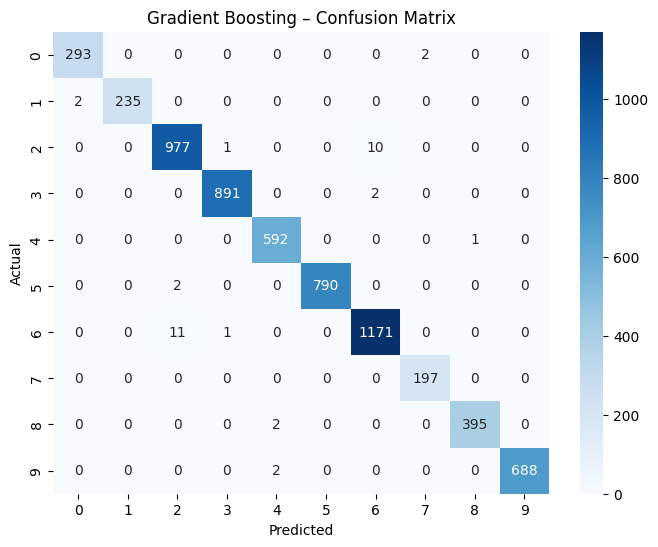

In [10]:
cm = confusion_matrix(y_test, y_pred2_gb)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot= True, fmt='d', cmap="Blues")
plt.title("Gradient Boosting – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

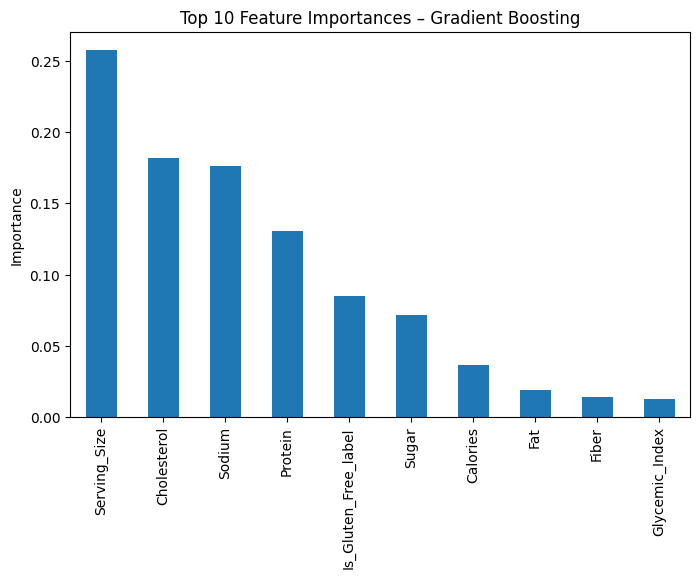

In [ ]:
import pandas as pd

gb_imp = pd.Series(gb.feature_importances_, index=X.columns)
gb_imp.sort_values(ascending=False).head(10).plot(
    kind="bar",
    figsize=(8,5),
    title="Top 10 Feature Importances – Gradient Boosting"
)
plt.ylabel("Importance")
plt.show()